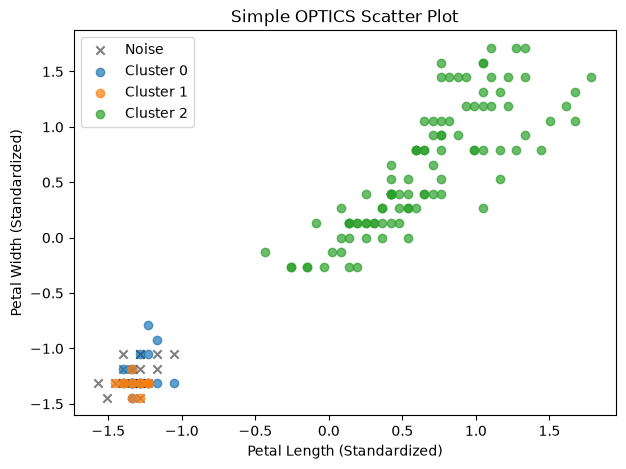

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import OPTICS
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y_true = iris.target  # Setosa=0, Versicolor=1, Virginica=2

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


optics_model = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
labels = optics_model.fit_predict(X_scaled)

unique_labels = np.unique(labels)

plt.figure(figsize=(7, 5))

# Draw the clusters found by the model
for klass in unique_labels:
    if klass == -1:
        # Draw noise/outliers as black X marks
        plt.scatter(X_scaled[labels == -1, 2], X_scaled[labels == -1, 3], 
                    c='black', marker='x', alpha=0.5, label='Noise')
    else:
        # Draw regular clusters as colored circles
        plt.scatter(X_scaled[labels == klass, 2], X_scaled[labels == klass, 3], 
                    alpha=0.7, label=f'Cluster {klass}')

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Simple OPTICS Scatter Plot")
plt.legend()
plt.show()


In [16]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 1. Compare the true species (y_true) against the model's labels
ari_score = adjusted_rand_score(iris.target, labels)
nmi_score = normalized_mutual_info_score(iris.target, labels)

print(f"Adjusted Rand Index (ARI): {ari_score:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.3f}")


Adjusted Rand Index (ARI): 0.397
Normalized Mutual Information (NMI): 0.607
